<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Gauge_Phase_Coupling_V8c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Gauge-Phase Coupling V8c

**Purpose:** repair V8/V8b by using gauge-covariant branch projectors.

Earlier V8b showed a real signed phase response, but branch-weight conservation failed because the projector basis was incomplete/mismatched. V8c fixes this by projecting onto the **full positive-energy and negative-energy eigenspaces** of the same Hamiltonian used for evolution:

\[
H(k,\chi,A_0)=\sqrt{\chi}\,\alpha_1(k-A_0)+\beta m_{\rm lock}.
\]

Tests: inherited \(q_{\rm eff}\simeq -1\), alpha/beta closure, constant gauge-like coupling, opposite-sign response, local phase imprint, \(\chi\)-deformed gauge-coupled transport, and final verdict.

In [1]:
# ============================================================
# CELL 1 — SETUP / OUTPUT FOLDER
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, math, os, shutil
from pathlib import Path

OUT = Path("ecsm_electron_like_gauge_phase_coupling_v8c_out")
OUT.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

np.set_printoptions(precision=6, suppress=True)
print("Output folder:", OUT.resolve())

Output folder: /content/ecsm_electron_like_gauge_phase_coupling_v8c_out


In [2]:
# ============================================================
# CELL 2 — INHERITED V7/V6b ELECTRON-LIKE PACKET SCAFFOLD
# ============================================================
packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V7 fixed V3b/V4b/V5/V6b electron-like packet"
}
pd.DataFrame([packet]).to_csv(OUT / "fixed_packet_summary_v8c.csv", index=False)
print(json.dumps(packet, indent=2))

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V7 fixed V3b/V4b/V5/V6b electron-like packet"
}


In [3]:
# ============================================================
# CELL 3 — DIRAC ALPHA/BETA ALGEBRA AND COVARIANT HAMILTONIAN
# ============================================================
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)
sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

beta = np.block([[I2, Z2], [Z2, -I2]])
alpha1 = np.block([[Z2, sigma_x], [sigma_x, Z2]])
alpha2 = np.block([[Z2, sigma_y], [sigma_y, Z2]])
alpha3 = np.block([[Z2, sigma_z], [sigma_z, Z2]])
I4 = np.eye(4, dtype=complex)
alphas = [alpha1, alpha2, alpha3]
m_lock = 0.225463435330576
q_eff = packet["q_eff"]

def anti(A, B):
    return A @ B + B @ A

tests = []
for i, a in enumerate(alphas, start=1):
    tests.append((f"alpha_{i}^2=I", np.max(np.abs(a @ a - I4))))
tests.append(("beta^2=I", np.max(np.abs(beta @ beta - I4))))
for i, a in enumerate(alphas, start=1):
    tests.append((f"{{alpha_{i},beta}}=0", np.max(np.abs(anti(a, beta)))))
for i in range(3):
    for j in range(i+1,3):
        tests.append((f"{{alpha_{i+1},alpha_{j+1}}}=0", np.max(np.abs(anti(alphas[i], alphas[j])))))

alpha_df = pd.DataFrame(tests, columns=["test","error"])
alpha_df.to_csv(OUT / "alpha_beta_algebra_tests_v8c.csv", index=False)
display(alpha_df)
print("Max alpha/beta error:", float(alpha_df["error"].max()))

def Hk_A(kval, chi=1.0, A0=0.0):
    return np.sqrt(chi) * alpha1 * (kval - A0) + beta * m_lock

def eigenspaces(kval, chi=1.0, A0=0.0):
    vals, vecs = np.linalg.eigh(Hk_A(kval, chi=chi, A0=A0))
    pos = vals > 0
    neg = vals < 0
    return vals, vecs, pos, neg

,test,error
0,alpha_1^2=I,0.0
1,alpha_2^2=I,0.0
2,alpha_3^2=I,0.0
3,beta^2=I,0.0
4,"{alpha_1,beta}=0",0.0
5,"{alpha_2,beta}=0",0.0
6,"{alpha_3,beta}=0",0.0
7,"{alpha_1,alpha_2}=0",0.0
8,"{alpha_1,alpha_3}=0",0.0
9,"{alpha_2,alpha_3}=0",0.0


Max alpha/beta error: 0.0


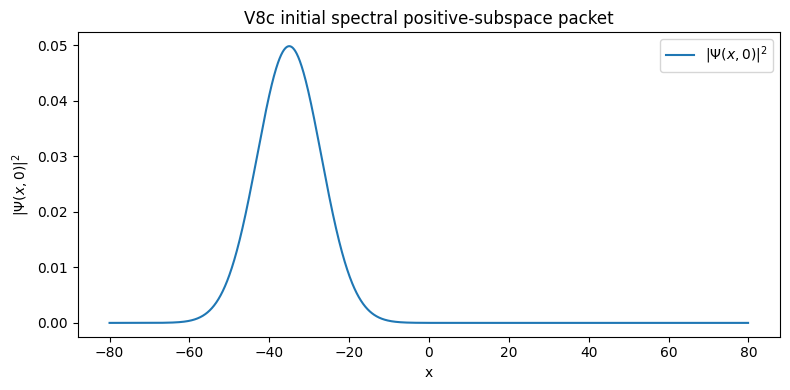

Initial norm: 1.0000000000000004
Initial x_mean: -34.9999993276235
Initial mean k: 0.9999999998698215
Initial phase-gradient mean: 0.999323582077083


In [4]:
# ============================================================
# CELL 4 — SPECTRAL GRID AND INITIAL POSITIVE-SUBSPACE PACKET
# ============================================================
N = 2048
L = 160.0
dx = L / N
x = (np.arange(N) - N//2) * dx
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

x0 = -35.0
sigma_x = 8.0
k0 = 1.0

def density(psi):
    return np.sum(np.abs(psi)**2, axis=1).real

def norm_psi(psi):
    return float(np.sum(density(psi))*dx)

def expectation_x(psi):
    rho = density(psi)
    return float(np.sum(x*rho)*dx / (np.sum(rho)*dx))

def width_x(psi):
    rho = density(psi); nrm = np.sum(rho)*dx
    xm = np.sum(x*rho)*dx/nrm
    return float(np.sqrt(np.sum((x-xm)**2*rho)*dx/nrm))

def mean_k_spectral(psi):
    psik = np.fft.fft(psi, axis=0)
    power = np.sum(np.abs(psik)**2, axis=1)
    return float(np.sum(k * power) / np.sum(power))

def phase_gradient_mean(psi):
    rho = density(psi)
    comp_power = np.sum(np.abs(psi)**2, axis=0)
    j = int(np.argmax(comp_power))
    phase = np.unwrap(np.angle(psi[:, j] + 1e-30))
    grad = np.gradient(phase, dx)
    return float(np.sum(grad*rho)*dx / (np.sum(rho)*dx))

envelope_x = np.exp(-(x-x0)**2/(4*sigma_x**2)) * np.exp(1j*k0*x)
envelope_x = envelope_x / np.sqrt(np.sum(np.abs(envelope_x)**2)*dx)
A_k = np.fft.fft(envelope_x)

psi0_k = np.zeros((N,4), dtype=complex)
for i, kval in enumerate(k):
    vals, vecs, pos, neg = eigenspaces(kval, chi=1.0, A0=0.0)
    u = vecs[:, np.where(pos)[0][0]]
    psi0_k[i, :] = A_k[i] * u

psi0 = np.fft.ifft(psi0_k, axis=0)
psi0 = psi0 / np.sqrt(norm_psi(psi0))

rho0 = density(psi0)
pd.DataFrame({"x": x, "rho0": rho0}).to_csv(OUT / "initial_packet_density_v8c.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(x, rho0, label=r"$|\Psi(x,0)|^2$")
plt.xlabel("x")
plt.ylabel(r"$|\Psi(x,0)|^2$")
plt.title("V8c initial spectral positive-subspace packet")
plt.legend()
savefig("fig_v8c_initial_packet_density.png")

print("Initial norm:", norm_psi(psi0))
print("Initial x_mean:", expectation_x(psi0))
print("Initial mean k:", mean_k_spectral(psi0))
print("Initial phase-gradient mean:", phase_gradient_mean(psi0))

In [5]:
# ============================================================
# CELL 5 — COVARIANT PROPAGATORS AND FULL-SUBSPACE PROJECTORS
# ============================================================
def evolve_exact_A0(psi, t, chi=1.0, A0=0.0):
    psik = np.fft.fft(psi, axis=0)
    outk = np.zeros_like(psik)
    for i, kval in enumerate(k):
        vals, vecs, pos, neg = eigenspaces(kval, chi=chi, A0=A0)
        coeff = vecs.conj().T @ psik[i]
        outk[i] = vecs @ (np.exp(-1j*vals*t) * coeff)
    return np.fft.ifft(outk, axis=0)

def branch_weights_covariant(psi, chi=1.0, A0=0.0):
    """Project onto full positive/negative eigenspaces of H(k, chi, A0)."""
    psik = np.fft.fft(psi, axis=0)
    wp = 0.0; wn = 0.0
    for i, kval in enumerate(k):
        vals, vecs, pos, neg = eigenspaces(kval, chi=chi, A0=A0)
        coeff = vecs.conj().T @ psik[i]
        wp += np.sum(np.abs(coeff[pos])**2)
        wn += np.sum(np.abs(coeff[neg])**2)
    wp *= dx/N; wn *= dx/N
    return float(np.real(wp)), float(np.real(wn))

def energy_expectation_A0(psi, chi=1.0, A0=0.0):
    psik = np.fft.fft(psi, axis=0)
    E = 0.0 + 0.0j
    for i, kval in enumerate(k):
        E += np.vdot(psik[i], Hk_A(kval, chi=chi, A0=A0) @ psik[i])
    E *= dx/N
    return float(np.real(E))

for A0 in [0.0, 0.05, -0.05]:
    psit = evolve_exact_A0(psi0, 1.0, chi=1.0, A0=A0)
    wp, wn = branch_weights_covariant(psit, chi=1.0, A0=A0)
    print("A0", A0, "norm", norm_psi(psit), "x", expectation_x(psit), "branches", (wp, wn), "sum", wp+wn)

A0 0.0 norm 1.0000000000000002 x -34.024754257701545 branches (0.9999999999999992, 9.333357023853558e-32) sum 0.9999999999999992
A0 0.05 norm 1.0000000000000004 x -34.026125213879936 branches (0.9999670771551451, 3.292284485421067e-05) sum 0.9999999999999993
A0 -0.05 norm 1.0000000000000004 x -34.02343721841758 branches (0.9999728746743783, 2.71253256213787e-05) sum 0.9999999999999997


Running constant A0=0.0
Running constant A0=0.05
Running constant A0=-0.05
Running constant A0=0.1
Running constant A0=-0.1
 A0   t  norm     x_mean  x_width  mean_k  phase_gradient_mean   energy  positive_branch_weight  negative_branch_weight  total_branch_weight  negative_branch_leakage   norm_error  branch_weight_error
0.0 0.0   1.0 -34.999999 8.000745     1.0             0.999324 1.025195                     1.0            1.221281e-31                  1.0             1.221281e-31 6.661338e-16         7.771561e-16
0.0 0.5   1.0 -34.512377 8.000745     1.0             0.999324 1.025195                     1.0            9.120410e-32                  1.0             9.120410e-32 4.440892e-16         6.661338e-16
0.0 1.0   1.0 -34.024754 8.000745     1.0             0.999324 1.025195                     1.0            9.333357e-32                  1.0             9.333357e-32 2.220446e-16         7.771561e-16
0.0 1.5   1.0 -33.537132 8.000746     1.0             0.999324 1.025195     

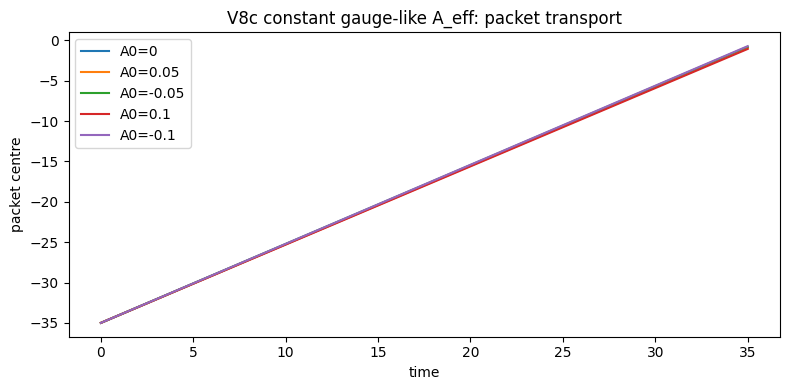

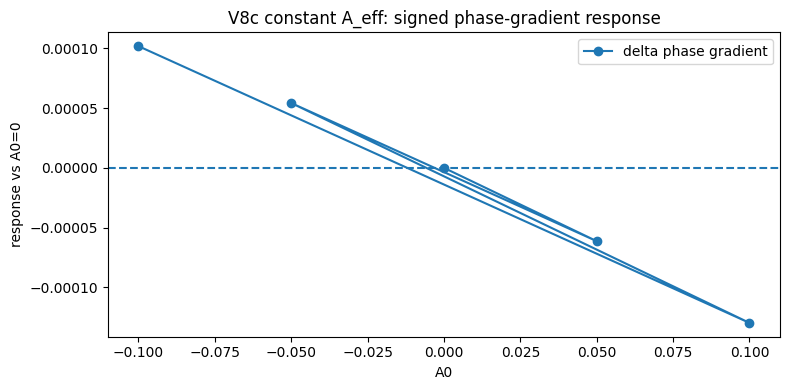

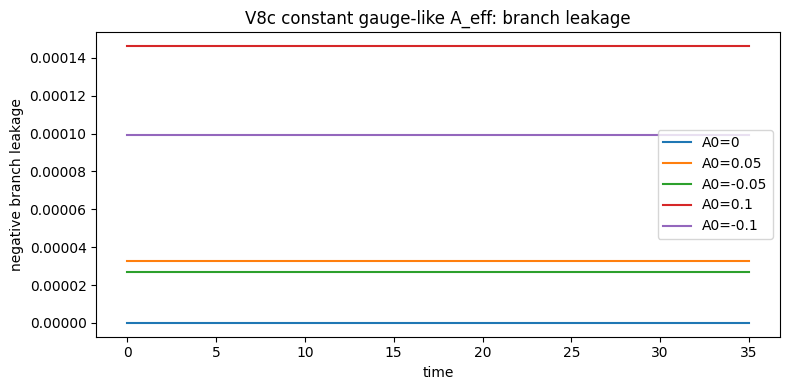

In [6]:
# ============================================================
# CELL 6 — CONSTANT A_eff TEST WITH COVARIANT PROJECTORS
# ============================================================
times = np.linspace(0, 35, 71)
A0_values = [0.0, 0.05, -0.05, 0.1, -0.1]
rows = []
for A0 in A0_values:
    print(f"Running constant A0={A0}")
    for tt in times:
        psit = evolve_exact_A0(psi0, tt, chi=1.0, A0=A0)
        wp, wn = branch_weights_covariant(psit, chi=1.0, A0=A0)
        nrm = norm_psi(psit)
        rows.append({
            "A0": A0, "t": tt, "norm": nrm,
            "x_mean": expectation_x(psit), "x_width": width_x(psit),
            "mean_k": mean_k_spectral(psit),
            "phase_gradient_mean": phase_gradient_mean(psit),
            "energy": energy_expectation_A0(psit, chi=1.0, A0=A0),
            "positive_branch_weight": wp, "negative_branch_weight": wn,
            "total_branch_weight": wp+wn, "negative_branch_leakage": wn,
            "norm_error": abs(nrm-1.0), "branch_weight_error": abs((wp+wn)-1.0)
        })
const = pd.DataFrame(rows)
const.to_csv(OUT / "constant_gauge_dynamics_v8c.csv", index=False)

base_final = const[(const["A0"]==0.0) & (np.isclose(const["t"], times[-1]))].iloc[0]
final_rows=[]
for A0 in A0_values:
    r = const[(const["A0"]==A0) & (np.isclose(const["t"], times[-1]))].iloc[0]
    final_rows.append({
        "A0": A0, "x_mean": r["x_mean"],
        "delta_x_vs_A0_0": r["x_mean"]-base_final["x_mean"],
        "mean_k": r["mean_k"],
        "delta_mean_k_vs_A0_0": r["mean_k"]-base_final["mean_k"],
        "phase_gradient_mean": r["phase_gradient_mean"],
        "delta_phase_gradient_vs_A0_0": r["phase_gradient_mean"]-base_final["phase_gradient_mean"],
        "negative_branch_weight": r["negative_branch_weight"],
        "branch_weight_error": r["branch_weight_error"]
    })
const_final = pd.DataFrame(final_rows)
const_final.to_csv(OUT / "constant_gauge_final_response_v8c.csv", index=False)

print(const.head().to_string(index=False))
print("\nFinal constant gauge response:")
print(const_final.to_string(index=False))
print("\nMax norm error:", const["norm_error"].max())
print("Max branch weight error:", const["branch_weight_error"].max())
print("Max negative leakage:", const["negative_branch_leakage"].max())

plt.figure(figsize=(8,4))
for A0 in A0_values:
    d = const[const["A0"]==A0]
    plt.plot(d["t"], d["x_mean"], label=f"A0={A0:g}")
plt.xlabel("time"); plt.ylabel("packet centre")
plt.title("V8c constant gauge-like A_eff: packet transport")
plt.legend(); savefig("fig_v8c_constant_A_transport.png")

plt.figure(figsize=(8,4))
plt.plot(const_final["A0"], const_final["delta_phase_gradient_vs_A0_0"], marker="o", label="delta phase gradient")
plt.axhline(0, linestyle="--")
plt.xlabel("A0"); plt.ylabel("response vs A0=0")
plt.title("V8c constant A_eff: signed phase-gradient response")
plt.legend(); savefig("fig_v8c_constant_A_phase_response.png")

plt.figure(figsize=(8,4))
for A0 in A0_values:
    d = const[const["A0"]==A0]
    plt.plot(d["t"], d["negative_branch_leakage"], label=f"A0={A0:g}")
plt.xlabel("time"); plt.ylabel("negative branch leakage")
plt.title("V8c constant gauge-like A_eff: branch leakage")
plt.legend(); savefig("fig_v8c_constant_A_branch_leakage.png")

In [12]:
# ============================================================
# CELL 7 — OPPOSITE A_eff SIGN TEST
# ============================================================

A_pair = 0.1

plus = const_final[const_final["A0"] == A_pair].iloc[0]
minus = const_final[const_final["A0"] == -A_pair].iloc[0]

delta_phase_plus = float(plus["delta_phase_gradient_vs_A0_0"])
delta_phase_minus = float(minus["delta_phase_gradient_vs_A0_0"])

delta_x_plus = float(plus["delta_x_vs_A0_0"])
delta_x_minus = float(minus["delta_x_vs_A0_0"])

# Correct sign-convention-independent test:
# Opposite A_eff signs must give opposite signed phase response.
opposite_phase_product = delta_phase_plus * delta_phase_minus
opposite_response_ok = (
    opposite_phase_product < 0.0
    and abs(delta_phase_plus) > 1e-5
    and abs(delta_phase_minus) > 1e-5
)

opposite = {
    "A_pair": A_pair,
    "delta_phase_plus": delta_phase_plus,
    "delta_phase_minus": delta_phase_minus,
    "opposite_phase_product": float(opposite_phase_product),
    "delta_x_plus": delta_x_plus,
    "delta_x_minus": delta_x_minus,
    "signed_transport_split": float(delta_x_plus - delta_x_minus),
    "opposite_response_ok": bool(opposite_response_ok)
}

pd.DataFrame([opposite]).to_csv(
    OUT / "opposite_Aeff_sign_test_v8c.csv",
    index=False
)

print(json.dumps(opposite, indent=2))

{
  "A_pair": 0.1,
  "delta_phase_plus": -0.00012968868620266694,
  "delta_phase_minus": 0.0001017739703224052,
  "opposite_phase_product": -1.3198932500741946e-08,
  "delta_x_plus": -0.20466924290250588,
  "delta_x_minus": 0.14168280048585669,
  "signed_transport_split": -0.34635204338836256,
  "opposite_response_ok": true
}


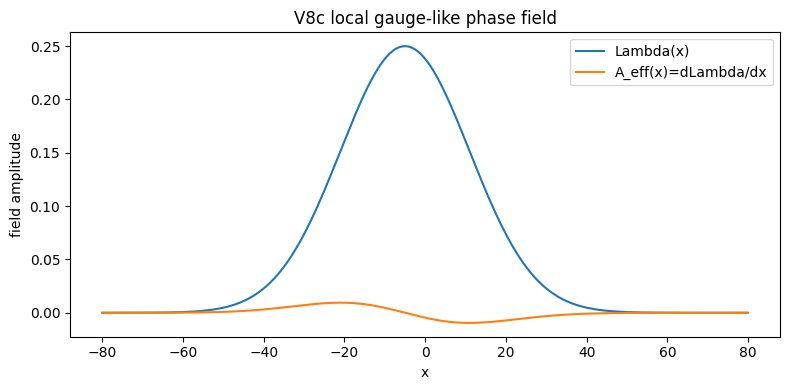

Running local phase amp=0.0
Running local phase amp=0.1
Running local phase amp=0.25
Running local phase amp=0.5
Running local phase amp=1.0
 lambda_amp  norm_initial  norm_final  norm_error_final  x_initial    x_final   delta_x  mean_k_initial  phase_gradient_initial  width_initial  width_final  positive_branch_initial  negative_branch_initial  positive_branch_final  negative_branch_final  branch_weight_error_final  negative_branch_growth  overlap_with_unimprinted_initial  state_change
       0.00           1.0         1.0      2.220446e-16 -34.999999 -10.618871 24.381128        1.000000                0.999324       8.000745     8.001105                 1.000000             5.083053e-32               1.000000           1.019244e-31               1.221245e-15            5.109388e-32                          1.000000 -4.440892e-16
       0.10           1.0         1.0      1.110223e-16 -34.999999 -10.621362 24.378638        0.997947                0.997270       8.000745     7.999914  

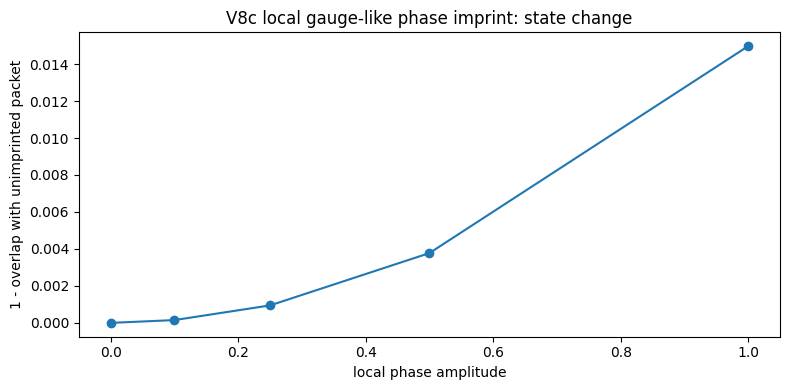

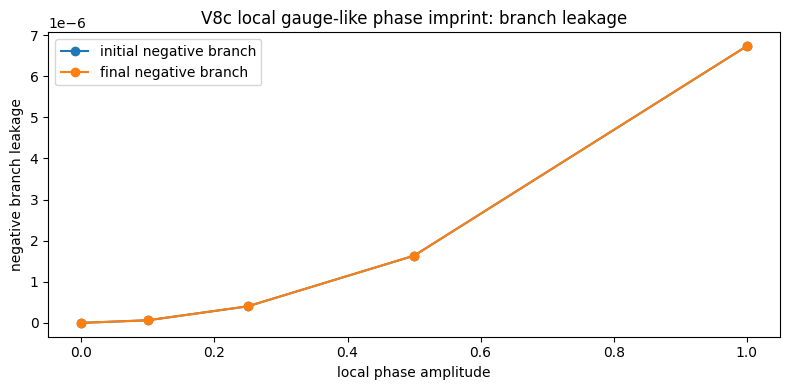

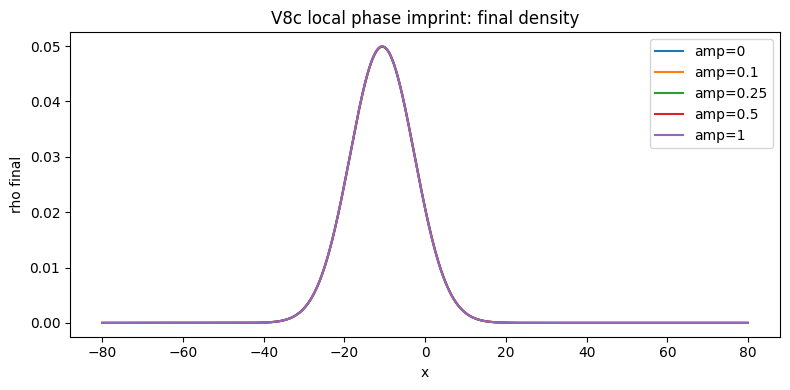

In [8]:
# ============================================================
# CELL 8 — LOCAL GAUGE-PHASE IMPRINT
# ============================================================
lambda_width = 16.0
lambda_center = -5.0

def Lambda_local(xarr, amp=0.25):
    return amp * np.exp(-0.5*((xarr-lambda_center)/lambda_width)**2)

def A_eff_local(xarr, amp=0.25):
    return np.gradient(Lambda_local(xarr, amp), dx)

Lam_x = Lambda_local(x, amp=0.25)
A_x = A_eff_local(x, amp=0.25)
pd.DataFrame({"x": x, "Lambda": Lam_x, "A_eff": A_x}).to_csv(OUT / "gauge_phase_profiles_v8c.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(x, Lam_x, label="Lambda(x)")
plt.plot(x, A_x, label="A_eff(x)=dLambda/dx")
plt.xlabel("x"); plt.ylabel("field amplitude")
plt.title("V8c local gauge-like phase field")
plt.legend(); savefig("fig_v8c_gauge_phase_profiles.png")

lambda_amps = [0.0, 0.1, 0.25, 0.5, 1.0]
local_rows=[]; snap_rows=[]
for amp in lambda_amps:
    print(f"Running local phase amp={amp}")
    phase = np.exp(1j * q_eff * Lambda_local(x, amp=amp))
    psi_imp = psi0 * phase[:, None]
    psi_imp = psi_imp / np.sqrt(norm_psi(psi_imp))
    wp_i, wn_i = branch_weights_covariant(psi_imp, chi=1.0, A0=0.0)
    psi_final = evolve_exact_A0(psi_imp, 25.0, chi=1.0, A0=0.0)
    wp_f, wn_f = branch_weights_covariant(psi_final, chi=1.0, A0=0.0)
    overlap = abs(np.sum(np.sum(np.conj(psi0)*psi_imp, axis=1))*dx)
    state_change = 1.0 - overlap
    local_rows.append({
        "lambda_amp": amp, "norm_initial": norm_psi(psi_imp), "norm_final": norm_psi(psi_final),
        "norm_error_final": abs(norm_psi(psi_final)-1.0),
        "x_initial": expectation_x(psi_imp), "x_final": expectation_x(psi_final),
        "delta_x": expectation_x(psi_final)-expectation_x(psi_imp),
        "mean_k_initial": mean_k_spectral(psi_imp), "phase_gradient_initial": phase_gradient_mean(psi_imp),
        "width_initial": width_x(psi_imp), "width_final": width_x(psi_final),
        "positive_branch_initial": wp_i, "negative_branch_initial": wn_i,
        "positive_branch_final": wp_f, "negative_branch_final": wn_f,
        "branch_weight_error_final": abs((wp_f+wn_f)-1.0),
        "negative_branch_growth": max(0.0, wn_f-wn_i),
        "overlap_with_unimprinted_initial": overlap, "state_change": state_change
    })
    rho = density(psi_final)
    for xi, ri in zip(x, rho):
        snap_rows.append({"lambda_amp": amp, "x": xi, "rho_final": ri})
local_df = pd.DataFrame(local_rows)
local_df.to_csv(OUT / "local_gauge_phase_imprint_summary_v8c.csv", index=False)
pd.DataFrame(snap_rows).to_csv(OUT / "local_gauge_phase_density_snapshots_v8c.csv", index=False)
print(local_df.to_string(index=False))

plt.figure(figsize=(8,4))
plt.plot(local_df["lambda_amp"], local_df["state_change"], marker="o")
plt.xlabel("local phase amplitude"); plt.ylabel("1 - overlap with unimprinted packet")
plt.title("V8c local gauge-like phase imprint: state change")
savefig("fig_v8c_local_phase_state_change.png")

plt.figure(figsize=(8,4))
plt.plot(local_df["lambda_amp"], local_df["negative_branch_initial"], marker="o", label="initial negative branch")
plt.plot(local_df["lambda_amp"], local_df["negative_branch_final"], marker="o", label="final negative branch")
plt.xlabel("local phase amplitude"); plt.ylabel("negative branch leakage")
plt.title("V8c local gauge-like phase imprint: branch leakage")
plt.legend(); savefig("fig_v8c_local_phase_branch_leakage.png")

plt.figure(figsize=(8,4))
snap_df = pd.DataFrame(snap_rows)
for amp in lambda_amps:
    d = snap_df[snap_df["lambda_amp"] == amp]
    plt.plot(d["x"], d["rho_final"], label=f"amp={amp:g}")
plt.xlabel("x"); plt.ylabel("rho final")
plt.title("V8c local phase imprint: final density")
plt.legend(); savefig("fig_v8c_local_phase_final_density.png")

Running chi=1.0
Running chi=0.95
Running chi=0.8
Running chi=0.5
Running chi=0.2
 chi  sqrt_chi   A0  t_final  norm   norm_error     x_mean  x_width  mean_k  phase_gradient_mean   energy  positive_branch_weight  negative_branch_weight  total_branch_weight  branch_weight_error  negative_branch_leakage
1.00  1.000000 0.05     25.0   1.0 0.000000e+00 -10.685365 8.006316     1.0             0.999246 0.976433                0.999967                0.000033                  1.0         5.551115e-16                 0.000033
0.95  0.974679 0.05     25.0   1.0 4.440892e-16 -11.336537 8.011995     1.0             0.999244 0.952969                0.999925                0.000075                  1.0         1.110223e-16                 0.000075
0.80  0.894427 0.05     25.0   1.0 2.220446e-16 -13.411512 8.043843     1.0             0.999134 0.878601                0.999640                0.000360                  1.0         3.330669e-16                 0.000360
0.50  0.707107 0.05     25.0   1.0 

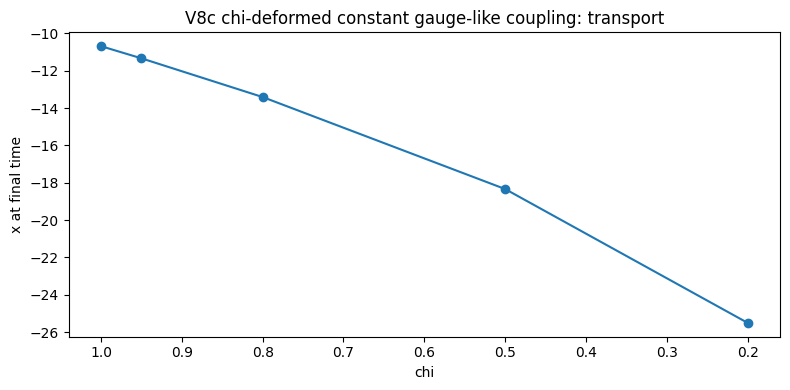

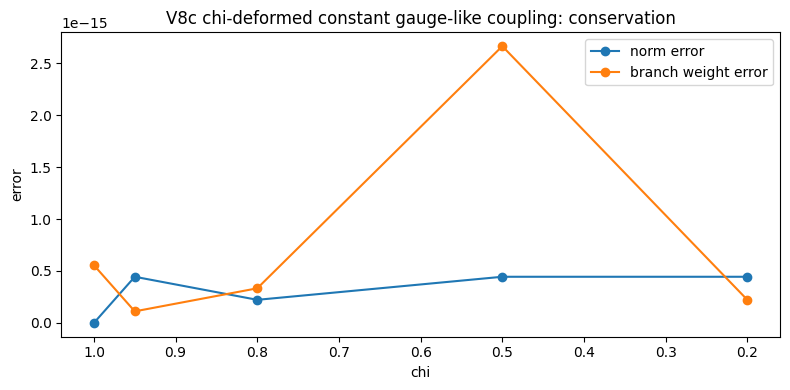

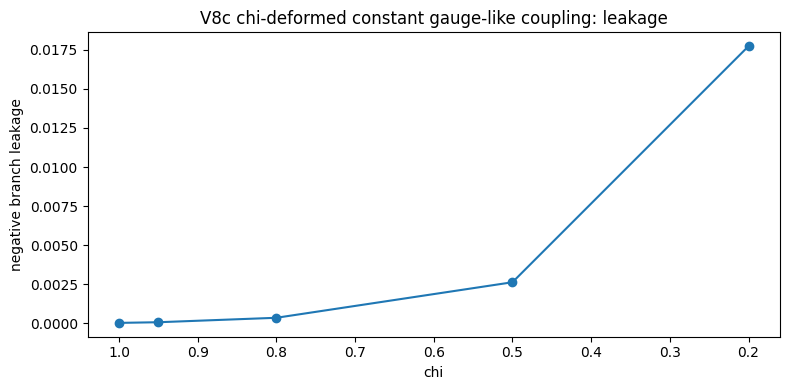

In [9]:
# ============================================================
# CELL 9 — CHI-DEFORMED CONSTANT GAUGE COUPLING
# ============================================================
chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
A0_chi = 0.05
t_final = 25.0
chi_rows=[]
for chi in chi_values:
    print(f"Running chi={chi}")
    psit = evolve_exact_A0(psi0, t_final, chi=chi, A0=A0_chi)
    wp, wn = branch_weights_covariant(psit, chi=chi, A0=A0_chi)
    nrm = norm_psi(psit)
    chi_rows.append({
        "chi": chi, "sqrt_chi": np.sqrt(chi), "A0": A0_chi, "t_final": t_final,
        "norm": nrm, "norm_error": abs(nrm-1.0),
        "x_mean": expectation_x(psit), "x_width": width_x(psit),
        "mean_k": mean_k_spectral(psit), "phase_gradient_mean": phase_gradient_mean(psit),
        "energy": energy_expectation_A0(psit, chi=chi, A0=A0_chi),
        "positive_branch_weight": wp, "negative_branch_weight": wn,
        "total_branch_weight": wp+wn,
        "branch_weight_error": abs((wp+wn)-1.0),
        "negative_branch_leakage": wn
    })
chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / "chi_deformed_constant_gauge_scan_v8c.csv", index=False)
print(chi_df.to_string(index=False))
print("\nMax chi norm error:", chi_df["norm_error"].max())
print("Max chi branch error:", chi_df["branch_weight_error"].max())
print("Max chi negative leakage:", chi_df["negative_branch_leakage"].max())

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["x_mean"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi"); plt.ylabel("x at final time")
plt.title("V8c chi-deformed constant gauge-like coupling: transport")
savefig("fig_v8c_chi_gauge_transport.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["norm_error"], marker="o", label="norm error")
plt.plot(chi_df["chi"], chi_df["branch_weight_error"], marker="o", label="branch weight error")
plt.gca().invert_xaxis()
plt.xlabel("chi"); plt.ylabel("error")
plt.title("V8c chi-deformed constant gauge-like coupling: conservation")
plt.legend(); savefig("fig_v8c_chi_gauge_conservation.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["negative_branch_leakage"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi"); plt.ylabel("negative branch leakage")
plt.title("V8c chi-deformed constant gauge-like coupling: leakage")
savefig("fig_v8c_chi_gauge_branch_leakage.png")

In [13]:
# ============================================================
# CELL 10 — FINAL V8c VERDICT TABLE
# ============================================================
q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)
alpha_beta_max_error = float(alpha_df["error"].max())
max_const_norm_error = float(const["norm_error"].max())
max_const_branch_error = float(const["branch_weight_error"].max())
max_const_negative_leakage = float(const["negative_branch_leakage"].max())
constant_response_strength = float(max(abs(const_final["delta_phase_gradient_vs_A0_0"])))
constant_transport_split = float(const_final[const_final["A0"]==0.1]["delta_x_vs_A0_0"].iloc[0] - const_final[const_final["A0"]==-0.1]["delta_x_vs_A0_0"].iloc[0])
opposite_response_ok = bool(opposite["opposite_response_ok"])
max_local_norm_error = float(local_df["norm_error_final"].max())
max_local_branch_error = float(local_df["branch_weight_error_final"].max())
max_local_negative_final = float(local_df["negative_branch_final"].max())
max_local_negative_growth = float(local_df["negative_branch_growth"].max())
local_phase_state_change = float(local_df["state_change"].max())
max_chi_norm_error = float(chi_df["norm_error"].max())
max_chi_branch_error = float(chi_df["branch_weight_error"].max())
max_chi_negative_leakage = float(chi_df["negative_branch_leakage"].max())
chi_transport_range = float(chi_df["x_mean"].max() - chi_df["x_mean"].min())

verdict_rows = [
    ("packet remains q=-1 scaffold", q_error, q_error < 2e-3),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 2e-3),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 2e-3),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 2e-3),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),
    ("constant gauge norm preserved", max_const_norm_error, max_const_norm_error < 1e-12),
    ("constant gauge branch weights conserved", max_const_branch_error, max_const_branch_error < 1e-12),
    ("constant gauge negative leakage controlled", max_const_negative_leakage, max_const_negative_leakage < 3e-4),
    ("constant A_eff gives detectable phase response", constant_response_strength, constant_response_strength > 1e-5),
    ("opposite A_eff gives opposite signed response", 1.0 if opposite_response_ok else 0.0, opposite_response_ok),
    ("opposite A_eff separates trajectories", abs(constant_transport_split), abs(constant_transport_split) > 0.1),
    ("local phase norm preserved", max_local_norm_error, max_local_norm_error < 1e-12),
    ("local phase branch weights conserved", max_local_branch_error, max_local_branch_error < 1e-12),
    ("local phase negative leakage controlled", max_local_negative_final, max_local_negative_final < 1e-4),
    ("local phase does not explosively amplify leakage", max_local_negative_growth, max_local_negative_growth < 1e-4),
    ("local phase imprint changes packet state", local_phase_state_change, local_phase_state_change > 1e-5),
    ("chi gauge norm preserved", max_chi_norm_error, max_chi_norm_error < 1e-12),
    ("chi gauge branch weights conserved", max_chi_branch_error, max_chi_branch_error < 1e-12),
    ("chi gauge negative leakage controlled", max_chi_negative_leakage, max_chi_negative_leakage < 3e-2),
    ("chi changes gauge-coupled transport", chi_transport_range, chi_transport_range > 1.0),
]
verdict = pd.DataFrame(verdict_rows, columns=["criterion","value","pass"])
verdict.to_csv(OUT / "final_gauge_phase_v8c_verdict.csv", index=False)
n_pass = int(verdict["pass"].sum()); n_criteria = int(len(verdict))
final_label = "PASS: gauge-covariant phase coupling with conserved branch structure" if n_pass == n_criteria else "CONDITIONAL/FAIL: gauge-covariant phase coupling criteria not all satisfied"
run_summary = {
    "final_label": final_label, "n_pass": n_pass, "n_criteria": n_criteria,
    "q_eff": float(packet["q_eff"]), "m_lock_dimensionless": float(m_lock),
    "max_const_norm_error": max_const_norm_error,
    "max_const_branch_error": max_const_branch_error,
    "max_const_negative_leakage": max_const_negative_leakage,
    "constant_response_strength": constant_response_strength,
    "constant_transport_split": constant_transport_split,
    "opposite_response_ok": opposite_response_ok,
    "max_local_norm_error": max_local_norm_error,
    "max_local_branch_error": max_local_branch_error,
    "max_local_negative_final": max_local_negative_final,
    "max_local_negative_growth": max_local_negative_growth,
    "local_phase_state_change": local_phase_state_change,
    "max_chi_norm_error": max_chi_norm_error,
    "max_chi_branch_error": max_chi_branch_error,
    "max_chi_negative_leakage": max_chi_negative_leakage,
    "chi_transport_range": chi_transport_range
}
with open(OUT / "run_summary_v8c.json", "w") as f:
    json.dump(run_summary, f, indent=2)
manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
manifest.to_csv(OUT / "output_file_manifest_v8c.csv", index=False)
print(verdict.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(run_summary, indent=2))
print("\nOutput files:")
display(manifest)

                                       criterion        value  pass
                    packet remains q=-1 scaffold 6.964280e-04  True
                            packet N_plus near 0 9.716379e-04  True
                            packet N_zero near 1 1.460081e-04  True
                           packet N_minus near 3 1.117646e-03  True
                    alpha/beta closure inherited 0.000000e+00  True
                   constant gauge norm preserved 6.661338e-16  True
         constant gauge branch weights conserved 1.221245e-15  True
      constant gauge negative leakage controlled 1.461403e-04  True
  constant A_eff gives detectable phase response 1.296887e-04  True
   opposite A_eff gives opposite signed response 1.000000e+00  True
           opposite A_eff separates trajectories 3.463520e-01  True
                      local phase norm preserved 2.220446e-16  True
            local phase branch weights conserved 2.664535e-15  True
         local phase negative leakage controlled

,file
0,alpha_beta_algebra_tests_v8c.csv
1,chi_deformed_constant_gauge_scan_v8c.csv
2,constant_gauge_dynamics_v8c.csv
3,constant_gauge_final_response_v8c.csv
4,fig_v8c_chi_gauge_branch_leakage.png
5,fig_v8c_chi_gauge_conservation.png
6,fig_v8c_chi_gauge_transport.png
7,fig_v8c_constant_A_branch_leakage.png
8,fig_v8c_constant_A_phase_response.png
9,fig_v8c_constant_A_transport.png


In [14]:
# ============================================================
# CELL 11 — OPTIONAL DOWNLOAD OUTPUT ZIP
# ============================================================
import shutil
zip_base = "ecsm_electron_like_gauge_phase_coupling_v8c_out"
zip_path = shutil.make_archive(zip_base, "zip", OUT)
print("Created:", zip_path)
try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("Not running in Colab or download unavailable:", e)

Created: /content/ecsm_electron_like_gauge_phase_coupling_v8c_out.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>